<a href="https://colab.research.google.com/github/JohnPaul0403/ai_notebooks/blob/main/ecm_on_forex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Factor Error Coefficient Model in the Forex Market

---

## Introduction

Pricing currency pairs in the Forex market is a complex task, as their implied values are often influenced by various internal and external factors. The observed market value of a currency pair may diverge from its true or "fair" value due to market inefficiencies, economic events, and other dynamic factors. One of the widely used methods to estimate the fair value of a currency is the **Error Coefficient Model (ECM)**. The main idea behind this model is to price an asset based on the value of a highly correlated asset.

The most basic form of the model is expressed as:

$$
P_a = P_b\beta + \alpha
$$

Here, $P_a$ is the price of the target asset, $P_b$ is the price of a correlated asset, $\beta$ is the coefficient that describes the relationship between them, and $\alpha$ is the intercept. The model gives us an estimate of the fair price of asset $a$ based on how it relates to asset $b$.

The **error term** from this model, which represents the difference between the actual and fair values, is given by:

$$
\epsilon = P_a - (P_b\beta + \alpha)
$$

This error term (\(\epsilon\)) reflects the spread between the observed market price and the theoretically fair price. The larger this spread, the more likely it is that the price will revert back to its fair value—assuming the relationship between the two assets is stable over time.

To validate this price reversion behavior, we require that the two assets are **cointegrated**. In particular, according to the Engle-Granger two-step method, cointegration is confirmed if:

$$
h_0 \ne 0
$$

In other words, if the null hypothesis of no cointegration is rejected, it implies that a stable, long-term equilibrium exists between the assets, and the model can be used to make reliable price predictions.

However, in real-world financial environments—especially in the Forex market—currency pairs are rarely influenced by just one other asset. They are often driven by a large number of macroeconomic and geopolitical factors such as interest rates, inflation, GDP, balance of trade, monetary policy decisions, and even market sentiment. To better capture these relationships, the model is generalized to the **Multi-Factor Error Coefficient Model (MFECM)**:

$$
P_a = \alpha + P_b\beta_1 + \sum_{j=2}^{n} X_j\beta_j
$$

Here, $X_j$ are additional explanatory variables (such as other currency prices, economic indicators, or market indices) that influence the price of asset \(a\). The goal of this approach is to improve the accuracy of price estimation by incorporating a broader understanding of the underlying market drivers.

In this notebook, we aim to explore and evaluate the Multi-Factor ECM model as a predictive tool for Forex asset pricing.

---

## Motivation

Accurate asset pricing is a cornerstone of quantitative finance, especially in strategies like statistical arbitrage where traders exploit temporary mispricings. Traditionally, valuation methods consider only the intrinsic value of an asset based on historical price data and statistical distributions. However, this view assumes that the asset self-determines its value, while in reality, asset prices are influenced by many external factors.

The strategy behind the MFECM is to break away from this isolated perspective and incorporate not only internal price behavior but also relationships with other relevant financial or economic variables. By analyzing how one currency is influenced by another or by various economic indicators, we create a more robust valuation system.

Unlike a simple correlation matrix that only shows whether two assets move together, the MFECM also helps determine *who is influencing whom*. This directionality is critical in building predictive financial models and in understanding the lead-lag relationships between currency pairs and market drivers.

By applying this model:

- We can identify long-term equilibrium relationships and exploit price deviations for mean-reversion strategies.
- We develop a deeper understanding of causality in currency markets, rather than relying solely on correlations.
- We integrate macroeconomic and market data into asset pricing models, improving both short-term trading signals and long-term valuation frameworks.

In conclusion, by leveraging the Multi-Factor Error Coefficient Model, we aim to create a more comprehensive and accurate representation of how Forex assets are priced and how they move relative to global financial conditions.

---

## Outline of the Project

1. **Data Collection**
   - Currency pair historical data
   - Macroeconomic indicators (such as CPI, interest rates, unemployment data)
   - Market indices and related financial instruments

2. **Preprocessing and Stationarity Testing**
   - Log transformations
   - Unit root tests (ADF, KPSS)

3. **Cointegration Testing**
   - Engle-Granger two-step method
   - Johansen test for multiple variables

4. **Model Construction**
   - Regression model for the Multi-Factor ECM
   - Residual analysis and error term validation

5. **Backtesting & Evaluation**
   - Testing mean-reversion strategies using historical error spreads
   - Performance metrics: Sharpe ratio, max drawdown, hit rate

6. **Deployment & Real-Time Monitoring**
   - Live error tracking
   - Signal generation and execution platform

---

## Conclusion

The Multi-Factor Error Coefficient Model provides a powerful framework to price Forex assets by considering a wide and practical set of economic drivers. By moving beyond single-factor models, we improve prediction accuracy and capture a more realistic view of what drives currency movements. This methodology allows traders and researchers to develop sophisticated strategies leveraging statistical inefficiencies, backed by economic rationale and robust statistical testing.




In [ ]:
# Importing basic libraries
from openbb import obb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm, statsmodels.tsa as tsa
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
resp = obb.currency.price.historical(symbol='CADUSD', start_date='2000-11-05', end_date='2025-11-05', provider='yfinance', interval="1d")
CAD = resp.to_dataframe()

In [ ]:
resp = obb.currency.price.historical(symbol='AUDUSD', start_date='2000-11-05', end_date='2025-11-05', provider='yfinance', interval="1d")
AUD = resp.to_dataframe()

In [ ]:
resp = obb.equity.price.historical(symbol='DX-Y.NYB', start_date='2000-11-05', end_date='2025-11-05', provider='yfinance', interval="1d")
usd = resp.to_dataframe()

In [ ]:
usd.head()

,open,high,low,close,volume
date,,,,,
2000-11-06,114.919998,116.139999,114.349998,115.690002,0
2000-11-07,115.459999,115.949997,115.150002,115.519997,0
2000-11-08,115.620003,116.620003,114.800003,116.230003,0
2000-11-09,116.279999,116.620003,115.099998,115.339996,0
2000-11-10,115.260002,115.900002,114.889999,115.790001,0


In [ ]:
# Getting Econmic data
cpi = obb.economy.cpi(country='united_states,canada', provider='fred').to_dataframe()
cpi = cpi.pivot_table(values='value', index=cpi.index, columns='country').dropna()
daily_dates = pd.date_range(start=cpi.index.min(), end=cpi.index.max(), freq='D')
cpi = cpi.reindex(daily_dates).ffill()
cpi.head()

country,canada,united_states
1956-01-01,0.007092,0.003745
1956-01-02,0.007092,0.003745
1956-01-03,0.007092,0.003745
1956-01-04,0.007092,0.003745
1956-01-05,0.007092,0.003745


In [ ]:
resp = obb.equity.price.historical(symbol='^TNX', start_date='2000-11-05', end_date='2025-11-05', provider='yfinance', interval="1d")
bond = resp.to_dataframe()
bond.head()

,open,high,low,close,volume
date,,,,,
2000-11-06,5.812,5.872,5.723,5.855,0
2000-11-07,5.859,5.885,5.829,5.859,0
2000-11-08,5.880,5.885,5.842,5.850,0
2000-11-09,5.829,5.833,5.770,5.808,0
2000-11-10,5.791,5.812,5.783,5.795,0


In [ ]:
# Getting all closing prices in one df
df = pd.concat([CAD["close"], AUD["close"], usd["close"], cpi, bond["close"]], axis=1)
df = df.dropna()
df.columns = ["cadusd", "audusd", "usdx", "cpi_ca", "cpi_us", "10yr"]
df.head()

,cadusd,audusd,usdx,cpi_ca,cpi_us,10yr
2006-05-16,0.903342,0.767106,84.169998,0.028116,0.041667,5.105
2006-05-17,0.896781,0.759417,84.849998,0.028116,0.041667,5.153
2006-05-18,0.893176,0.764000,84.510002,0.028116,0.041667,5.073
2006-05-19,0.894935,0.757174,84.879997,0.028116,0.041667,5.054
2006-05-22,0.895496,0.753409,84.349998,0.028116,0.041667,5.036


Text(0, 0.5, 'Returns')

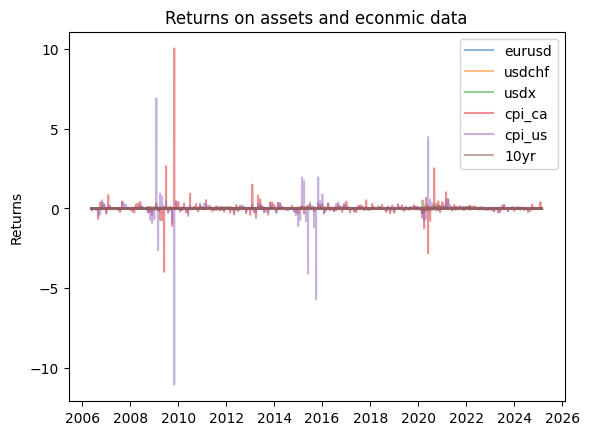

In [ ]:
# Plotting chf, eur prices and us index
df.pct_change().dropna().plot(alpha=0.5)
plt.title("Returns on assets and econmic data")
plt.ylabel("Returns")

In [ ]:
# Looking at the log returns
df_log_returns = np.log(df).diff().dropna()
df_log_returns.head()

/Users/johnpaulparedes/OpenBB/conda/envs/openbb/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


,cadusd,audusd,usdx,cpi_ca,cpi_us,10yr
2006-05-17,-0.007290,-0.010075,0.008046,0.0,0.0,0.009359
2006-05-18,-0.004027,0.006017,-0.004015,0.0,0.0,-0.015647
2006-05-19,0.001967,-0.008975,0.004369,0.0,0.0,-0.003752
2006-05-22,0.000627,-0.004985,-0.006264,0.0,0.0,-0.003568
2006-05-23,-0.007227,-0.003234,0.000000,0.0,0.0,0.005939


Text(0.5, 1.0, 'Log returns between CAD/USD and AUD/USD pairs')

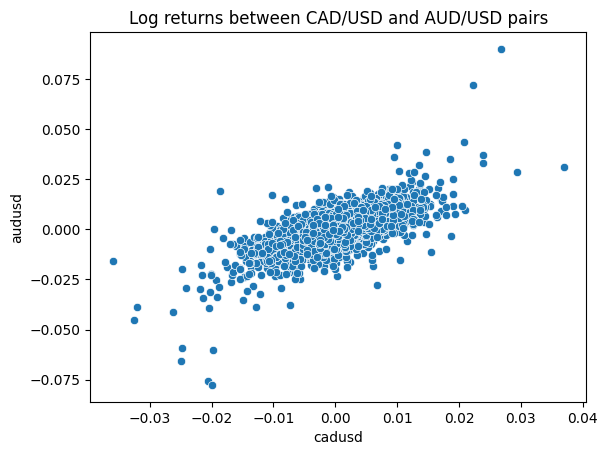

In [ ]:
# Plotting the log returns eur vs chf
sns.scatterplot(x=df_log_returns["cadusd"], y=df_log_returns["audusd"])
plt.title("Log returns between CAD/USD and AUD/USD pairs")

Text(0.5, 1.0, 'Log returns between CAD/USD and USDX index')

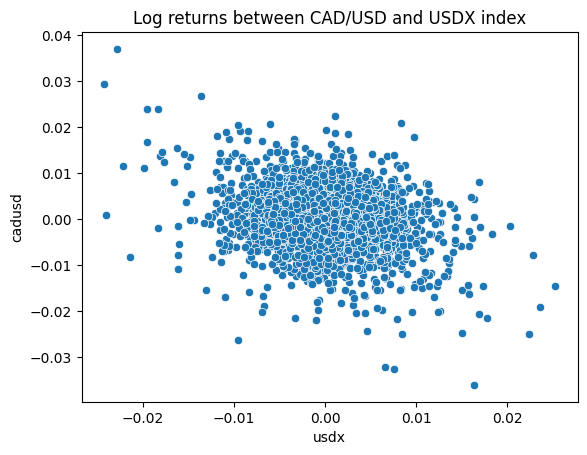

In [ ]:
# Plotting the log returns eur vs usdx
sns.scatterplot(y=df_log_returns["cadusd"], x=df_log_returns["usdx"])
plt.title("Log returns between CAD/USD and USDX index")

Text(0.5, 1.0, 'Log returns between AUD/USD and USDX index')

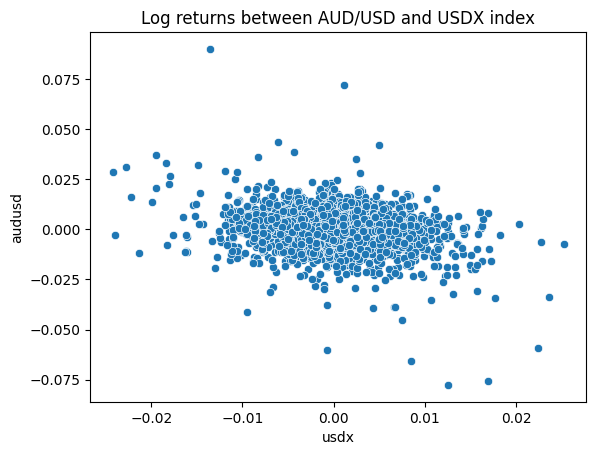

In [ ]:
# Plotting the log returns usdchf vs usdx
sns.scatterplot(y=df_log_returns["audusd"], x=df_log_returns["usdx"])
plt.title("Log returns between AUD/USD and USDX index")

### Notes.-

As we can see it looks like the log returns between AUD/USD and CAD/USD are correlated, but we also see certain outliers in the data, that way indicate that this relationship was broken in the past, we also can tell that this relationship is between in the 1d data, since this experiment is more of proof of cancept, more than a full scope between both coins, there is no need for lower frecuency data. For real world applications the must be 1s or tick data ideally, this with the objective to find the most minimal misallgiment between both assets. In terms of next steps, we must test whether or not one is moving the other, after this test we can start building our model feature by feauture using different techniques for model selection.

---

### Next steps

Now we will need to use a test for cointigretion, in this case we have 3 important assets, which are the most important for this case, the first 2 are the coin pairs and the last one the USD index or USDX. These 3 assets alone can be very powerfull, but the last most important asset is the 10yr treasury bond from the us markets. We will test and find out which one is moving each one and see which assets will should bet on, of our coins.

In [ ]:
# Testing only for cadusd to audusd
print(tsa.stattools.grangercausalitytests(pd.concat([df["cadusd"], df["audusd"]], axis=1), maxlag=5))


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5230  , p=0.2172  , df_denom=4708, df_num=1
ssr based chi2 test:   chi2=1.5239  , p=0.2170  , df=1
likelihood ratio test: chi2=1.5237  , p=0.2171  , df=1
parameter F test:         F=1.5230  , p=0.2172  , df_denom=4708, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.9170  , p=0.3998  , df_denom=4705, df_num=2
ssr based chi2 test:   chi2=1.8359  , p=0.3993  , df=2
likelihood ratio test: chi2=1.8355  , p=0.3994  , df=2
parameter F test:         F=0.9170  , p=0.3998  , df_denom=4705, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3742  , p=0.2487  , df_denom=4702, df_num=3
ssr based chi2 test:   chi2=4.1288  , p=0.2479  , df=3
likelihood ratio test: chi2=4.1270  , p=0.2481  , df=3
parameter F test:         F=1.3742  , p=0.2487  , df_denom=4702, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.8381  , p=0.

In [ ]:
# Testing only for audusd and cadusd
print(tsa.stattools.grangercausalitytests(pd.concat([df["audusd"], df["cadusd"]], axis=1), maxlag=5))


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.6450  , p=0.1997  , df_denom=4708, df_num=1
ssr based chi2 test:   chi2=1.6461  , p=0.1995  , df=1
likelihood ratio test: chi2=1.6458  , p=0.1995  , df=1
parameter F test:         F=1.6450  , p=0.1997  , df_denom=4708, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.7889  , p=0.1673  , df_denom=4705, df_num=2
ssr based chi2 test:   chi2=3.5816  , p=0.1668  , df=2
likelihood ratio test: chi2=3.5803  , p=0.1669  , df=2
parameter F test:         F=1.7889  , p=0.1673  , df_denom=4705, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.5775  , p=0.1926  , df_denom=4702, df_num=3
ssr based chi2 test:   chi2=4.7395  , p=0.1919  , df=3
likelihood ratio test: chi2=4.7371  , p=0.1921  , df=3
parameter F test:         F=1.5775  , p=0.1926  , df_denom=4702, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.8869  , p=0.

In [ ]:
tsa.stattools.coint(df["audusd"], df["cadusd"])

(np.float64(-3.4643261103299343),
 np.float64(0.03569155864682435),
 array([-3.89876626, -3.33742729, -3.0453504 ]))

In [ ]:
tsa.stattools.coint(df["cadusd"], df["audusd"])

(np.float64(-3.4172894760920216),
 np.float64(0.04046610898654167),
 array([-3.89876626, -3.33742729, -3.0453504 ]))

In [ ]:
tsa.stattools.coint(df["audusd"], df["cadusd"])

(np.float64(-3.4643261103299343),
 np.float64(0.03569155864682435),
 array([-3.89876626, -3.33742729, -3.0453504 ]))

### Results Interpretation

For this part we can tell that infact the both coins are cointigrated, this basically means that both can move the other in a 95% confidence interval. This a great start since this is daily data and capturing this relationsips are not so common. Looking at the Granger Causaulity test, we see how in this case CAD is moving AUD, in other words, to build our model, we will put AUD as our asset a and CAD as the asset b being this the one moving the price of the other asset. Once again it is important to notice that this is just daily data and it should not bring great confidence at the moment to actually trade this model, real spread strategies are used in tick or 1s data to capture any price movement in the market.

---

### Next Steps

We will start building our model, we know that the most important parts are, the asset a (AUD/USD) and asset b (CAD/USD), these are non-negotiable in our model. Then we have our helper features, in this case, USD-index, CPI, 10yr interest rate, this features can explain about the asset, but are not essential to price the asset itself, therefore we will add them all-togheter and test which features should stay and which not. For this process, first will extract essential data from our features, we want un-correlated data to the target. Then we will build n-1 models (n is the amount of features) to test how well each model reacts. We will test using the T-test and understand which features to use.

In [ ]:
# Splitting our data
X = df.drop("audusd", axis=1)
y = df["audusd"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

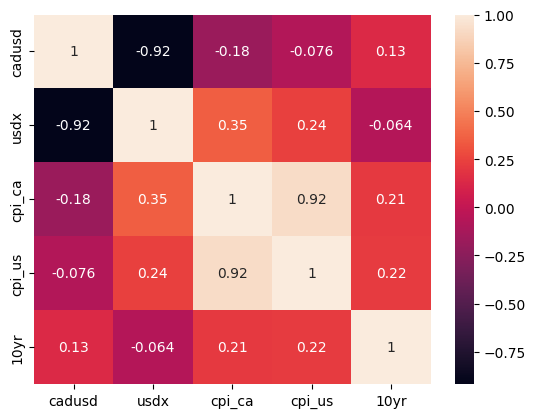

In [ ]:
# Looking at the correlation between independent variables
sns.heatmap(X.corr(), annot=True)
plt.show()

In [ ]:
# Selecting features based on the t-test
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

# Get scores for each feature
scores = selector.scores_
feature_names = X.columns

# Getting a nice table
feature_scores = pd.DataFrame({
    'Feature': feature_names,
    'Score': scores
})

# Sort by score descending
feature_scores = feature_scores.sort_values(by='Score', ascending=False)
print(feature_scores)

  Feature         Score
0  cadusd  23760.862111
1    usdx   9163.379257
2  cpi_ca    169.608657
3  cpi_us     58.240218
4    10yr     25.698587


In [ ]:
# Getting the pvalues
selector.pvalues_

array([0.00000000e+00, 0.00000000e+00, 5.87805236e-38, 2.92104318e-14,
       4.18317071e-07])

In [ ]:
# Creating our first model with standard scaler to see the actual coefficients values
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [ ]:
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [ ]:
model.named_steps["model"].coef_

array([ 0.14149974,  0.02308694,  0.00536999, -0.01007844, -0.02673419])

In [ ]:
model.named_steps["model"].coef_

array([ 0.14149974,  0.02308694,  0.00536999, -0.01007844, -0.02673419])

In [ ]:
# Letting SKlearn pick the features
sfs = SequentialFeatureSelector(model, n_features_to_select=3, direction='forward')
sfs.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,n_features_to_select,3
,tol,None
,direction,'forward'
,scoring,None
,cv,5
,n_jobs,None
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True


In [ ]:
sfs.get_feature_names_out()

array(['cadusd', 'usdx', '10yr'], dtype=object)

In [ ]:
# Using LassoCV to find the most important features
model_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(cv=5, random_state=42))
])
model_cv.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True


In [ ]:
# Show coefficients
lasso_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_cv.named_steps["model"].coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)
lasso_coef_df

,Feature,Coefficient
0,cadusd,0.139766
4,10yr,-0.026544
1,usdx,0.021492
3,cpi_us,-0.008506
2,cpi_ca,0.004021


### Notes.-

After looking at the different models, all of them give the CPI values as insignificant, which it was expected since they are only aproxmation of the real price, in the other hand the CAD/USD and 10yr bonds are the most important ones which makes a lot of since in terms of macroeconomic data, we understand that values such as the 10yr treasury bond affects the values of the US dollar making the exchanges rate move.

---

### Next Steps

We will start fitting 2 models, the first one is without the 3 most insignificant features and the other with the significant features, in this sense we will take only the model with the highest values in terms of $R^2$ test and MAE test, the MAE will tell us the epsilon of the model and help us to get the confidence intervals. The most important after running this test we will choose the model and use Statmodels to find out other important aspects of the model itself for future iterations. We also know that non linear assets can be price in using neural networks for the best possible estimator.

In [ ]:
selected_features = ["cadusd", "10yr"]

# Fitting our model with the selected features
model_selected = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [ ]:
model_selected.fit(X_train[selected_features], y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [ ]:
# Fitting our model with all features
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [ ]:
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [ ]:
# Evaluate with reduced features vs full model
y_pred_full = model.predict(X_val)
y_pred_selected = model_selected.predict(X_val[selected_features])

In [ ]:
print("Full Model R2:", r2_score(y_val, y_pred_full))
print("Reduced Model R2:", r2_score(y_val, y_pred_selected))
print("Full Model MAE:", mean_absolute_error(y_val, y_pred_full))
print("Reduced Model MAE:", mean_absolute_error(y_val, y_pred_selected))

Full Model R2: 0.9094079105764646
Reduced Model R2: 0.905051326755516
Full Model MAE: 0.03050931624425787
Reduced Model MAE: 0.031150899158645762


In [ ]:
# Fitting an ols model with only the selected features
X_const = sm.add_constant(X[selected_features])
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 audusd   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                 2.276e+04
Date:                Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:02:42   Log-Likelihood:                 8682.0
No. Observations:                4712   AIC:                        -1.736e+04
Df Residuals:                    4709   BIC:                        -1.734e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1055      0.005    -22.598      0.0

In [ ]:
# Fitting an ols model with only all the features
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 audusd   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     9672.
Date:                Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:03:27   Log-Likelihood:                 8813.2
No. Observations:                4712   AIC:                        -1.761e+04
Df Residuals:                    4706   BIC:                        -1.758e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4660      0.025    -18.303      0.0

### Notes.-

After carefully looking at each model we can see how our reduced model has better performance and how it can actually handle way better the prediction of y meaining that this model is working properly and is the best possible model from all the models, based purely on all our features. This maens that the model coefficients predicts the assets accordingly to what is expected to be predicted.

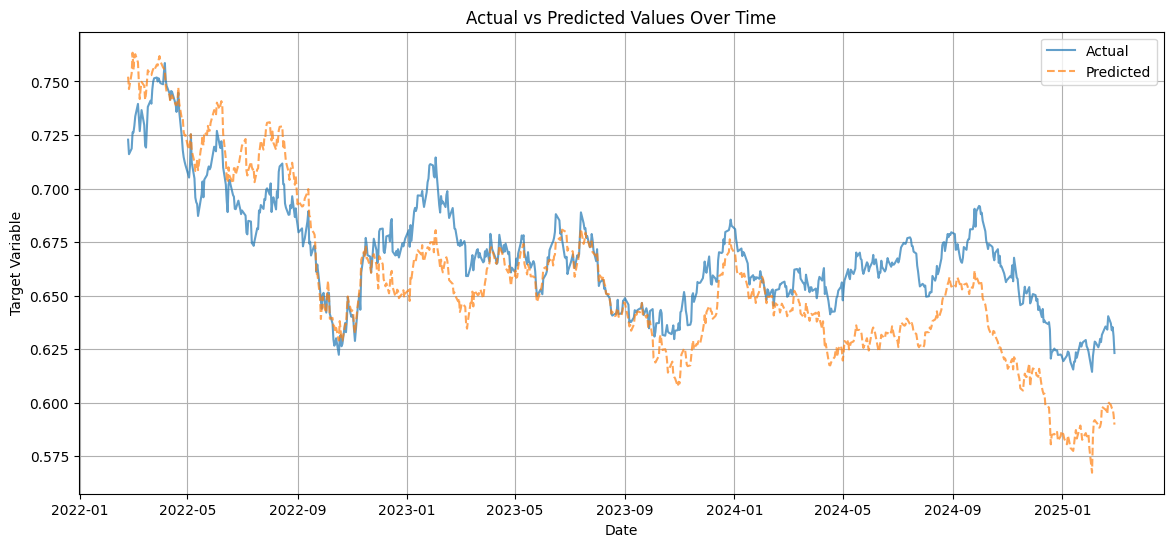

In [ ]:
y_pred = model_selected.predict(df[selected_features].tail(252*3))

plot_df = pd.DataFrame({
    'Actual': y.tail(252*3),
    'Predicted': y_pred
})
plot_df.set_index(df.tail(252*3).index)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(x=plot_df.index, y=plot_df['Actual'], label='Actual', alpha=0.7)
sns.lineplot(x=plot_df.index, y=plot_df['Predicted'], label='Predicted', alpha=0.7, linestyle='--')

plt.title('Actual vs Predicted Values Over Time')
plt.xlabel('Date')
plt.ylabel('Target Variable')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
df = pd.concat([df[selected_features], y], axis=1)
df.head()

,cadusd,10yr,audusd
2006-05-16,0.903342,5.105,0.767106
2006-05-17,0.896781,5.153,0.759417
2006-05-18,0.893176,5.073,0.764000
2006-05-19,0.894935,5.054,0.757174
2006-05-22,0.895496,5.036,0.753409


In [ ]:
df.to_csv("forex_data.csv")

### Conclusions

As we can tell from the results, the model successfully captures the pricing dynamics of the asset pair, indicating that the relationship between the variables is statistically significant and consistent with market behavior. However, the **error margin remains relatively high**, suggesting that while the model effectively explains most of the price variation, it does not fully capture all underlying market factors influencing the asset’s value.

This residual error may indicate that the model is detecting instances where the asset is **temporarily overvalued or undervalued**, implying potential **mean-reversion opportunities**. In other words, deviations from the model’s fair price may represent short-term inefficiencies that are expected to correct over time.

Given that most of the dataset consists of **daily observations**, it is also possible that **mean reversion occurs over longer horizons**, meaning the adjustment toward the equilibrium price may take several days or even weeks. This highlights the importance of temporal context when interpreting the error term — short-term deviations may not always imply model inaccuracy but rather reflect the natural lag of market correction mechanisms.

In conclusion, while the model demonstrates strong explanatory power, further refinement could be achieved by:

- Incorporating additional **macro-financial variables** that may influence price movements (e.g., interest rate differentials, commodity prices, or monetary policy indicators).
- Testing **nonlinear relationships** or **interaction effects** between variables.
- Evaluating **different time resolutions** (e.g., weekly or intraday) to better capture the timing of mean reversion.

Overall, the reduced Multi-Factor Error Coefficient Model provides a **robust and interpretable foundation** for forecasting and pricing in the Forex market, while leaving room for further enhancements to improve its precision and adaptability under changing market conditions.
